<div align="center">
    <img src="https://www.sharif.ir/documents/20124/0/logo-fa-IR.png/4d9b72bc-494b-ed5a-d3bb-e7dfd319aec8?t=1609608338755" alt="Logo" width="200">
    <p><b>HW2 @ Deep Learning Course, Dr. Soleymani</b></p>
    <p><b>Desinged by Erfan Yeganegi</b></p>
</div>

---




*Full Name:*
Amirhosein Rezaei

*Student Number:*
401105989

# CAPTCHA Segmentation and Classification

Welcome to the CAPTCHA Solver assignment. Your objective is to build a robust pipeline capable of segmenting overlapping digits from noisy backgrounds and classifying them using a convolutional neural network.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

## Environment Setup and Data Generation

To ensure we have a virtually infinite and well-understood dataset, we will generate synthetic CAPTCHAs dynamically. The function below creates CAPTCHAs with overlapping digits, random rotations, Gaussian noise, and sinusoidal distractor lines.

> ⚠️ **DO NOT MODIFY THIS CELL.** The hyperparameters defined in the global scope are fixed for this assignment to ensure grading consistency. Run this cell to initialize the environment and the generation function.

In [2]:
CAPTCHA_SHAPE = (80, 240)
CAPTCHA_LENGTH = 5     
NUM_DISTRACTOR_LINES = 5
NOISE_LEVEL = 0.045  
OVERLAP_FRACTION = 0.35

In [3]:
def synthesize_captcha_image():
    """
    Generates a single synthetic CAPTCHA image and its corresponding segmentation mask.
    """
    img = np.zeros((CAPTCHA_SHAPE[0], CAPTCHA_SHAPE[1], 3), dtype=np.float32)
    c1 = np.random.uniform(0.8, 1.0, 3) 
    c2 = np.random.uniform(0.7, 0.9, 3)
    
    for x in range(CAPTCHA_SHAPE[1]):
        ratio = x / CAPTCHA_SHAPE[1]
        img[:, x, :] = c1 * (1 - ratio) + c2 * ratio
        
    mask = np.zeros(CAPTCHA_SHAPE[:2], dtype=np.uint8)
    
    digits = []
    last_digit = -1
    for _ in range(CAPTCHA_LENGTH):
        d = random.randint(0, 9)
        while d == last_digit:
            d = random.randint(0, 9)
        digits.append(str(d))
        last_digit = d
    
    margin = 30
    available_width = CAPTCHA_SHAPE[1] - 2 * margin
    standard_step = available_width / max(1, CAPTCHA_LENGTH - 1)
    x_step = standard_step * (1.0 - OVERLAP_FRACTION)
    
    total_span = x_step * (CAPTCHA_LENGTH - 1)
    x_start = (CAPTCHA_SHAPE[1] - total_span) / 2
    
    for i, d in enumerate(digits):
        char_canvas = np.zeros(CAPTCHA_SHAPE[:2], dtype=np.uint8)
        
        scale = random.uniform(1.8, 2.2) 
        thickness = random.randint(2, 3)
        angle = random.uniform(-25, 25)
        
        x = int(x_start + i * x_step + random.uniform(-5, 5))
        y = int(CAPTCHA_SHAPE[0] * 0.65 + random.uniform(-5, 5))
        
        cv2.putText(char_canvas, d, (x, y), cv2.FONT_HERSHEY_TRIPLEX, scale, 255, thickness, cv2.LINE_AA)
        
        M = cv2.getRotationMatrix2D((x, y - 20), angle, 1.0)
        char_canvas = cv2.warpAffine(char_canvas, M, (CAPTCHA_SHAPE[1], CAPTCHA_SHAPE[0]))
        
        text_pixels = char_canvas > 0
        text_color = np.random.uniform(0.1, 0.4, 3)
        img[text_pixels] = text_color
        
        overlap_pixels = (mask > 0) & text_pixels
        mask[text_pixels] = int(d) + 1
        mask[overlap_pixels] = 11
        
    for _ in range(NUM_DISTRACTOR_LINES):
        line_color = np.random.uniform(0.3, 0.7, 3)
        amplitude = random.uniform(5, 15)
        frequency = random.uniform(0.02, 0.06)
        phase = random.uniform(0, 2 * np.pi)
        y_offset = random.uniform(20, 60) 
        
        pts = []
        for x in range(-CAPTCHA_SHAPE[1], CAPTCHA_SHAPE[1] * 2):
            y = int(y_offset + amplitude * np.sin(frequency * x + phase))
            pts.append([x, y])
            
        pts = np.array(pts, dtype=np.float32).reshape((-1, 1, 2))
        line_angle = random.uniform(-45, 45) 
        center = (CAPTCHA_SHAPE[1] // 2, CAPTCHA_SHAPE[0] // 2)
        M_line = cv2.getRotationMatrix2D(center, line_angle, 1.0)
        rotated_pts = cv2.transform(pts, M_line).astype(np.int32)
        
        cv2.polylines(img, [rotated_pts], isClosed=False, color=line_color, thickness=2, lineType=cv2.LINE_AA)
    
    if NOISE_LEVEL > 0:
        noise = np.random.normal(0, NOISE_LEVEL, img.shape)
        img = np.clip(img + noise, 0, 1)
    
    return img, mask, "".join(digits)

## Data Visualization

Before designing our segmentation architecture, it is crucial to visually verify our data. Deep learning models are only as good as the ground truth they are trained on. 

The segmentation masks generated by `synthesize_captcha_image()` contain 12 mutually exclusive classes:
*   `0`: Background
*   `1` through `10`: The digits '0' through '9'
*   `11`: Overlapping regions (where two characters intersect)

**Task:** Complete the cell below to generate 5 sample CAPTCHAs. Plot the raw image on the left and its corresponding segmentation mask on the right. You must choose an appropriate colormap and set value boundaries to clearly differentiate all 12 classes.

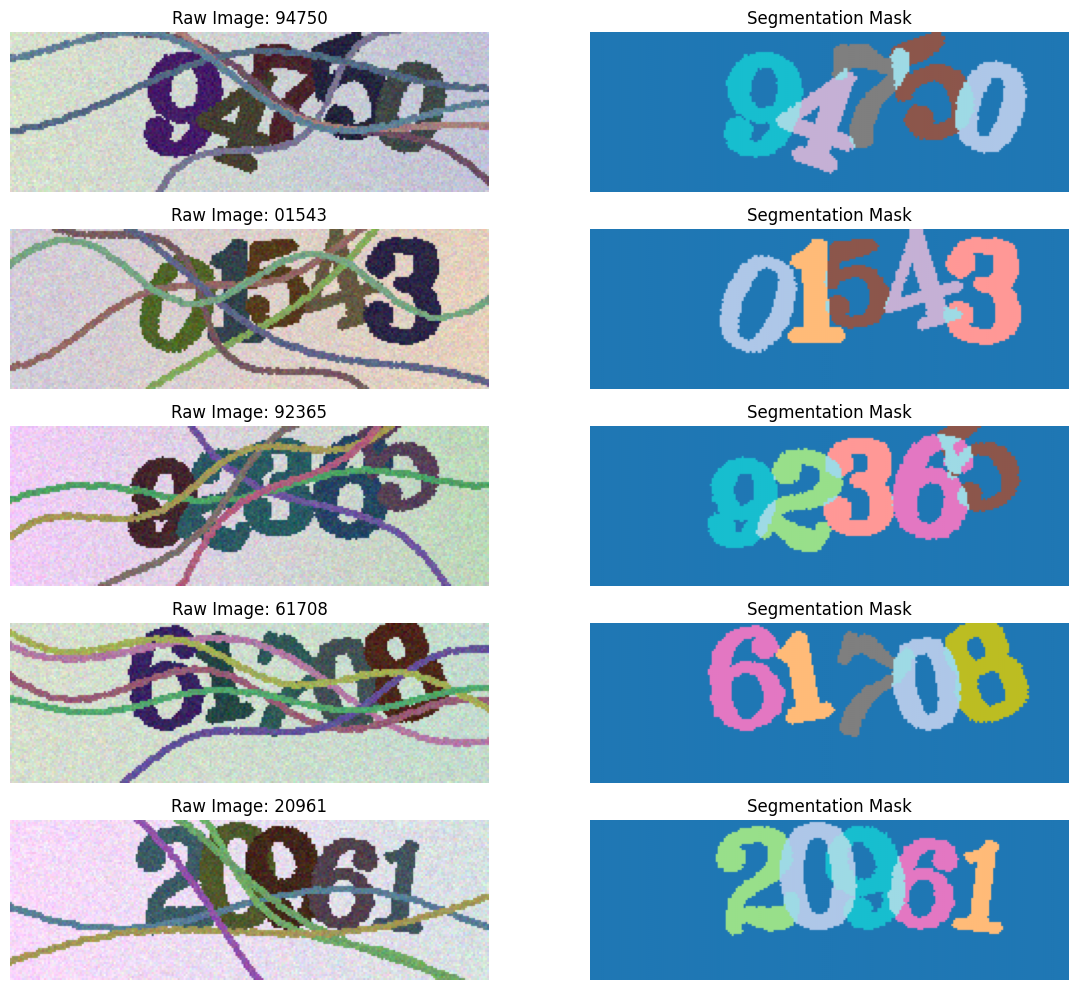

In [5]:
num_images = 5

fig, axs = plt.subplots(num_images, 2, figsize=(12, 10))

for i in range(num_images):
    # 1. Generate a sample image, mask, and target text using your environment setup.
    img, mask, text = synthesize_captcha_image()
    
    # 2. Plot the raw image in the first column.
    axs[i, 0].imshow(img)
    axs[i, 0].set_title(f'Raw Image: {text}')
    axs[i, 0].axis('off')
    
    # 3. Plot the segmentation mask in the second column.
    im = axs[i, 1].imshow(mask, cmap='tab20', vmin=0, vmax=11)
    axs[i, 1].set_title('Segmentation Mask')
    axs[i, 1].axis('off')
    
plt.tight_layout()
plt.show()

## PyTorch Data Pipeline

One of the massive advantages of synthetic data is that we technically have an infinite dataset. However, an "epoch" in PyTorch needs a defined length so the optimizer knows when to step and log metrics. 

**Hardware Constraints & Grading Note:**
If you are training on a standard laptop (CPU or GPU), processing tens of thousands of samples per epoch might take too long. You are encouraged to adjust the `NUM_TRAIN_SAMPLES`, `NUM_VAL_SAMPLES`, and `BATCH_SIZE` parameters below to fit your hardware capabilities. 

*However*, remember that deep learning thrives on data. If you reduce the dataset size too drastically to speed up training, your model will overfit and fail the final accuracy evaluation. Finding the right balance between computational efficiency and high validation accuracy is part of your grade!

In [9]:
class CaptchaDataset(Dataset):
    def __init__(self, num_samples):
        self.num_samples = num_samples

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Generate a single sample using our globally configured generator
        img, mask, text = synthesize_captcha_image()
        
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() 
        mask_tensor = torch.from_numpy(mask).long()
        
        return img_tensor, mask_tensor, text

NUM_TRAIN_SAMPLES = 2048
NUM_VAL_SAMPLES = 512
BATCH_SIZE = 32

train_dataset = CaptchaDataset(NUM_TRAIN_SAMPLES)
val_dataset = CaptchaDataset(NUM_VAL_SAMPLES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches per epoch: {len(train_loader)}")
print(f"Validation batches per epoch: {len(val_loader)}")

Train batches per epoch: 64
Validation batches per epoch: 16


## Semantic Segmentation with U-Net

To separate the overlapping digits from the background and each other, we will frame this as a **pixel-wise multi-class classification** problem (Semantic Segmentation). For this task, we will build a lightweight version of the famous **U-Net** architecture.

A U-Net consists of three main parts:
1.  **The Encoder:** A series of convolutions and max-pooling layers that capture context and extract deep feature representations. Spatial dimensions are reduced while channel depth increases.
2.  **The Bottleneck:** The deepest part of the network bridging the encoder and decoder.
3.  **The Decoder:** A series of transposed convolutions (upsampling) that restore the spatial dimensions. 
    * **Skip Connections** are used to concatenate high-resolution features from the encoder directly to the decoder. This prevents the loss of spatial precision, which is vital for drawing tight boundaries around our overlapping digits.

**Task:** Complete the `MicroUNet` architecture below. You will need to implement the standard `ConvBlock`, define the upsampling layers in the decoder, and properly wire the skip connections in the `forward` pass. Finally, initialize the model, loss function, and optimizer.

In [10]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class MicroUNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=12):
        super().__init__()

        self.enc1 = ConvBlock(in_channels, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)
        self.pool = nn.MaxPool2d(2)
        
        self.b = ConvBlock(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(256, 128)
        
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(128, 64)
        
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(64, 32)
        
        self.out = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool(e1)
        
        e2 = self.enc2(p1)
        p2 = self.pool(e2)
        
        e3 = self.enc3(p2)
        p3 = self.pool(e3)

        b = self.b(p3)
        
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)

# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = MicroUNet(in_channels=3, num_classes=12).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Training

It is time to train the `MicroUNet`. A standard PyTorch training loop consists of iterating over epochs, and within each epoch, iterating over batches of data. 

For each batch, we must strictly follow these steps:
1.  **Zero the Gradients:** Clear old gradients from the last step.
2.  **Forward Pass:** Pass the input tensors through the model.
3.  **Compute Loss:** Calculate how far off the predictions are from the ground truth using our criterion.
4.  **Backward Pass:** Compute the derivative of the loss with respect to the model parameters.
5.  **Optimizer Step:** Update the weights based on the computed gradients.

**Task:** Write the training and validation loops below. 

Epoch 1/10 [Train]:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1 Summary -> Train Loss: 1.5222 | Val Loss: 1.0171


Epoch 2/10 [Train]:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 2/10 [Val]:   0%|          | 0/16 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 9 Summary -> Train Loss: 0.0556 | Val Loss: 0.0515


Epoch 10/10 [Train]:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 10 Summary -> Train Loss: 0.0497 | Val Loss: 0.0464


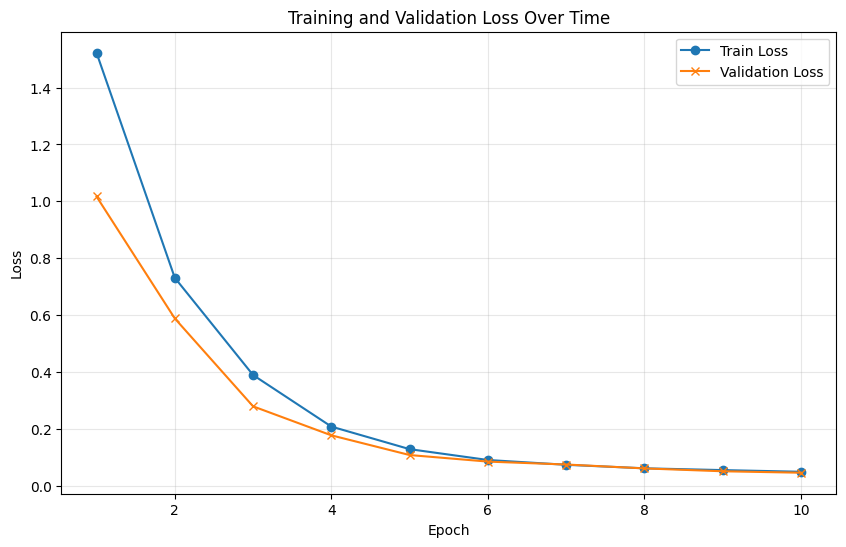

In [11]:
NUM_EPOCHS = 10

train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    batch_losses = []
    
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for imgs, masks, _ in train_pbar:        
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        
        outputs = model(imgs)
        
        loss = criterion(outputs, masks)
        
        loss.backward()
        
        optimizer.step()
        
        batch_losses.append(loss.item())
        train_pbar.set_postfix({'loss': loss.item()})
        
    train_losses.append(np.mean(batch_losses))
    
    model.eval()
    batch_val_losses = []
    
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]")
    with torch.no_grad():
        for imgs, masks, _ in val_pbar:
            imgs = imgs.to(device)
            masks = masks.to(device)
            
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            
            batch_val_losses.append(loss.item())
            val_pbar.set_postfix({'loss': loss.item()})
            
    val_losses.append(np.mean(batch_val_losses))
    
    # Print epoch summary
    print(f"Epoch {epoch+1} Summary -> Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")


plt.figure(figsize=(10, 6))
plt.plot(range(1, NUM_EPOCHS+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, NUM_EPOCHS+1), val_losses, label='Validation Loss', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Qualitative Evaluation

Now that our `MicroUNet` is trained, we need to inspect its predictions visually. A decreasing loss curve is a good sign, but it does not guarantee that the model is performing exactly how we want—especially on the overlapping class (Class 11) and the complex noise lines.

**Task:** Complete the cell below to perform inference on a single batch from the validation set. 

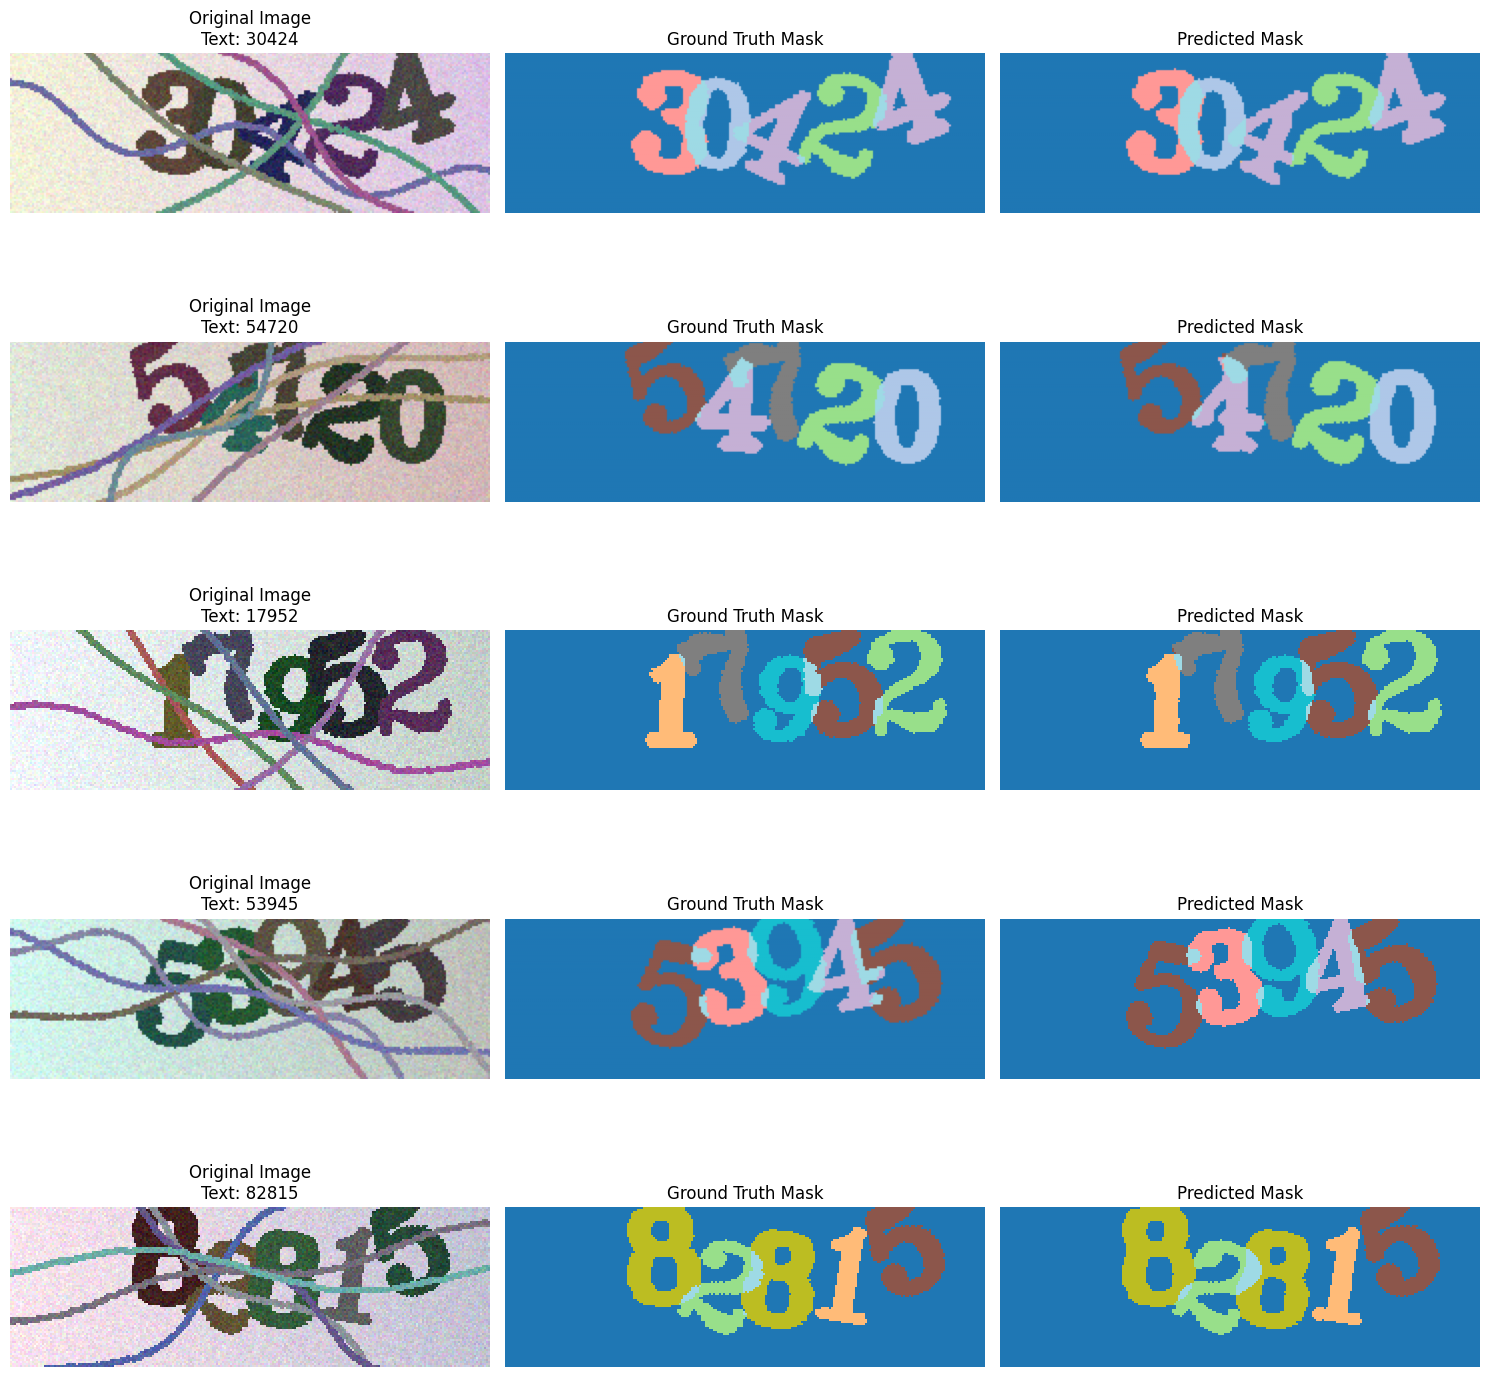

In [12]:
imgs, masks, texts = next(iter(val_loader))

model.eval()

with torch.no_grad():
    imgs = imgs.to(device)
    outputs = model(imgs)
    
    preds = torch.argmax(outputs, dim=1)
    
    preds_np = preds.cpu().numpy()
    imgs_np = imgs.cpu().permute(0, 2, 3, 1).numpy()
    masks_np = masks.cpu().numpy()

num_images = 5
fig, axs = plt.subplots(num_images, 3, figsize=(15, 3 * num_images))

for i in range(num_images):
    axs[i, 0].imshow(imgs_np[i])
    axs[i, 0].set_title(f'Original Image\nText: {texts[i]}')
    axs[i, 0].axis('off')
    
    axs[i, 1].imshow(masks_np[i], cmap='tab20', vmin=0, vmax=11)
    axs[i, 1].set_title('Ground Truth Mask')
    axs[i, 1].axis('off')
    
    axs[i, 2].imshow(preds_np[i], cmap='tab20', vmin=0, vmax=11)
    axs[i, 2].set_title('Predicted Mask')
    axs[i, 2].axis('off')
    
plt.tight_layout()
plt.show()

## From Segmentation to Sequence Recognition

Now that our U-Net can successfully segment the overlapping characters from the noisy background, we need a way to actually "read" them. We are transitioning from a **Segmentation** task to a **Sequence Recognition** task. 

Instead of feeding the raw, noisy image into our classifier, we can feed it the clean segmentation mask. By converting our 12-class mask into a simple 0-1 binary "attention map", we drastically reduce the complexity the classifier has to learn.

**Task:** Complete the `SequenceRecognitionDataset` class below. 
1. Convert the generated multi-class mask into a binary mask (1 for any text/overlap, 0 for background).
2. Ensure the binary mask has a channel dimension `(1, H, W)` so it can be ingested by a standard CNN.
3. Convert the ground-truth string (e.g., `"49201"`) into a 1D tensor of integers (`[4, 9, 2, 0, 1]`).

In [13]:
class SequenceRecognitionDataset(Dataset):
    def __init__(self, num_samples):
        self.num_samples = num_samples

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        img, mask, text = synthesize_captcha_image()
        
        binary_mask = (mask > 0).astype(np.float32)
        
        mask_tensor = torch.from_numpy(binary_mask).unsqueeze(0).float()
        
        target_tensor = torch.tensor([int(char) for char in text], dtype=torch.long)
        
        return mask_tensor, target_tensor, text

NUM_SEQ_TRAIN = 4096
NUM_SEQ_VAL = 1024
BATCH_SIZE_SEQ = 32

seq_train_dataset = SequenceRecognitionDataset(NUM_SEQ_TRAIN)
seq_val_dataset = SequenceRecognitionDataset(NUM_SEQ_VAL)

seq_train_loader = DataLoader(seq_train_dataset, batch_size=BATCH_SIZE_SEQ, shuffle=True)
seq_val_loader = DataLoader(seq_val_dataset, batch_size=BATCH_SIZE_SEQ, shuffle=False)

print(f"Sequence Train batches: {len(seq_train_loader)}")
print(f"Sequence Val batches: {len(seq_val_loader)}")

Sequence Train batches: 128
Sequence Val batches: 32


## The Sequence Reader (CNN with Parallel Outputs)

To predict the sequence of 5 characters from our binary mask, we will build a `SequenceReaderCNN`. This architecture processes the `(1, H, W)` binary mask through a shared **Convolutional Backbone** to extract spatial features. 

Instead of using a recurrent neural network (RNN) to predict the sequence step-by-step, we will leverage the fixed length of our CAPTCHAs (5 characters). We will flatten the feature map and feed it into 5 separate, parallel **Classification Heads**. Each head is a simple Multi-Layer Perceptron responsible for predicting a single character at a specific position.

**Task:** Complete the `SequenceReaderCNN` below. 

In [14]:
import torch.nn as nn
import torch.optim as optim

class SequenceReaderCNN(nn.Module):
    def __init__(self, in_channels=1, sequence_length=5, num_classes=10):
        super().__init__()
        
        self.backbone = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.AdaptiveAvgPool2d((5, 10))
        )
        
        self.flatten = nn.Flatten()

        flattened_size = 64 * 5 * 10
        
        hidden_size = 256
        self.heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(flattened_size, hidden_size),
                nn.ReLU(inplace=True),
                nn.Linear(hidden_size, num_classes)
            ) for _ in range(sequence_length)
        ])

    def forward(self, x):
        features = self.backbone(x)
        features = self.flatten(features)
        
        outputs = []
        for head in self.heads:
            outputs.append(head(features))
        
        return outputs

reader_model = SequenceReaderCNN(in_channels=1, sequence_length=5, num_classes=10)
reader_model = reader_model.to(device)

reader_optimizer = optim.Adam(reader_model.parameters(), lr=0.001)
reader_criterion = nn.CrossEntropyLoss()

## Training the Sequence Reader 

Training our `SequenceReaderCNN` introduces a new challenge. Unlike our U-Net which had a single output tensor, this model outputs a **list of 5 separate tensors** (one for each character position). 

Because the classification heads are independent, we must calculate the `CrossEntropyLoss` for *each* head against its corresponding target character, and then **sum** the 5 separate losses together.

**Task:** Write the training loop for the `SequenceReaderCNN`.

Training Sequence Reader...


Epoch 1/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 1/10 - Avg Summed Loss: 5.9702


Epoch 2/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 2/10 - Avg Summed Loss: 2.1437


...

Epoch 8/10 - Avg Summed Loss: 0.2986


Epoch 9/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 9/10 - Avg Summed Loss: 0.2838


Epoch 10/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 10/10 - Avg Summed Loss: 0.2445


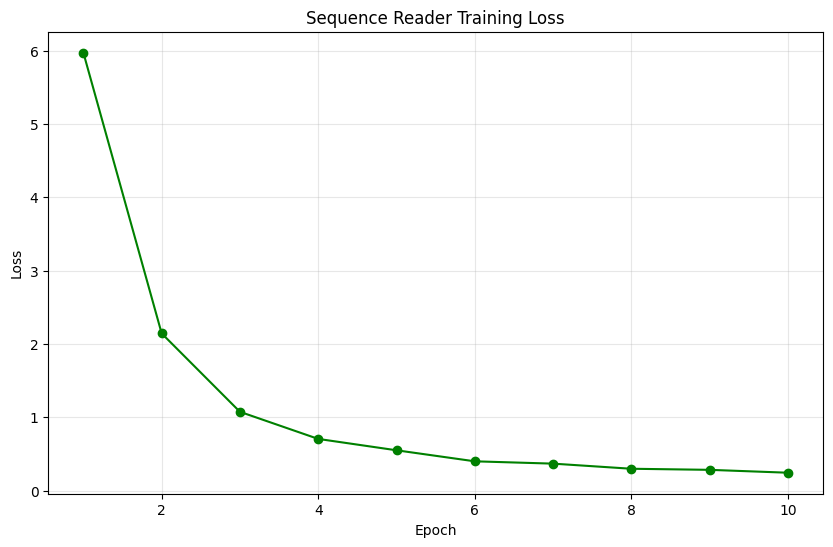

In [16]:
print("Training Sequence Reader...")

NUM_EPOCHS = 10
reader_train_losses = []

for epoch in range(NUM_EPOCHS):
    reader_model.train()
    batch_losses = []
    
    seq_pbar = tqdm(seq_train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False)
    for masks, targets, _ in seq_pbar:
        masks = masks.to(device)
        targets = targets.to(device)
        
        reader_optimizer.zero_grad()
        
        outputs = reader_model(masks)
        
        loss = 0
        for i in range(5):
            loss += reader_criterion(outputs[i], targets[:, i])
        
        loss.backward()
        reader_optimizer.step()
        
        batch_losses.append(loss.item())
        seq_pbar.set_postfix({'Summed Loss': loss.item()})
        
    epoch_loss = sum(batch_losses) / len(batch_losses)
    reader_train_losses.append(epoch_loss)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Avg Summed Loss: {epoch_loss:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, NUM_EPOCHS+1), reader_train_losses, marker='o', color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Sequence Reader Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

## Inference and Evaluation

The model is trained, but neural networks output raw logits, not strings. In this step, we must bridge the gap between PyTorch tensors and human-readable text.

**Task:** Complete the cell below to perform a final visual evaluation.

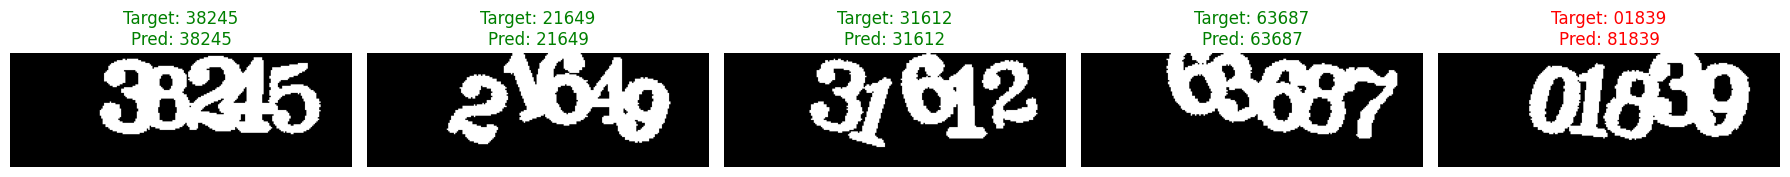

In [25]:
reader_model.eval()

masks, targets, true_texts = next(iter(seq_val_loader))

masks = masks.to(device)

with torch.no_grad():
    outputs = reader_model(masks)

outputs_cpu = [out.cpu() for out in outputs]

batch_predictions = []

for batch_idx in range(masks.shape[0]):
    predicted_string = ""
    for head_idx in range(5):
        pred_digit = torch.argmax(outputs_cpu[head_idx][batch_idx]).item()
        predicted_string += str(pred_digit)
    batch_predictions.append(predicted_string)


num_display = 5
fig, axs = plt.subplots(1, num_display, figsize=(18, 4))

for i in range(num_display):
    mask_img = masks[i].cpu().squeeze().numpy()
    true_txt = true_texts[i]
    pred_txt = batch_predictions[i]
    
    axs[i].imshow(mask_img, cmap='gray')
    
    color = "green" if true_txt == pred_txt else "red"
    axs[i].set_title(f'Target: {true_txt}\nPred: {pred_txt}', color=color, fontsize=12)
    axs[i].axis('off')

plt.tight_layout()
plt.show()

## The Baseline Model

We have built a complex, two-stage pipeline: U-Net (Segmentation) $\rightarrow$ Sequence Reader (Classification). But was all that effort actually necessary? What if we just fed the raw, noisy RGB image directly into a CNN and asked it to predict the 5 digits? 

In deep learning, we answer this question by establishing a **Baseline**. An ablation study removes a specific component of a system to see how much performance degrades. Here, we will remove the U-Net. 

**Task:** Complete the `BaselineCaptchaDataset` below.

In [26]:
class BaselineCaptchaDataset(Dataset):
    def __init__(self, num_samples):
        self.num_samples = num_samples

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        img, _, text = synthesize_captcha_image()
        
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float()
        
        target_tensor = torch.tensor([int(char) for char in text], dtype=torch.long)
        
        return img_tensor, target_tensor, text 
    
NUM_BASELINE_TRAIN = 4096
    
baseline_model = SequenceReaderCNN(in_channels=3, sequence_length=5, num_classes=10).to(device)
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

baseline_train_dataset = BaselineCaptchaDataset(NUM_BASELINE_TRAIN)
baseline_train_loader = DataLoader(baseline_train_dataset, batch_size=BATCH_SIZE_SEQ, shuffle=True)

print(f"Baseline Train batches: {len(baseline_train_loader)}")

Baseline Train batches: 128


## Training the Baseline Model

We will now train our baseline model using the raw RGB images. 

**Conceptual Check:** Think about the task this baseline network is being asked to perform. Our two-stage pipeline explicitly separated the tasks: the U-Net learned spatial segmentation, and the Sequence Reader learned character classification. This baseline model must learn to ignore the background gradient, ignore the sinusoidal distractor lines, separate the overlapping pixels, *and* classify the characters all at the exact same time. Do you expect it to perform better or worse?

**Task:** Write the training loop for the baseline model.

Training Naive Baseline Model (Raw Image -> Text)...


Epoch 1/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 1/10 - Baseline Loss: 11.5018


Epoch 2/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 2/10 - Baseline Loss: 8.3959


...

Epoch 8/10 - Baseline Loss: 1.5725


Epoch 9/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 9/10 - Baseline Loss: 1.4376


Epoch 10/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 10/10 - Baseline Loss: 1.3364


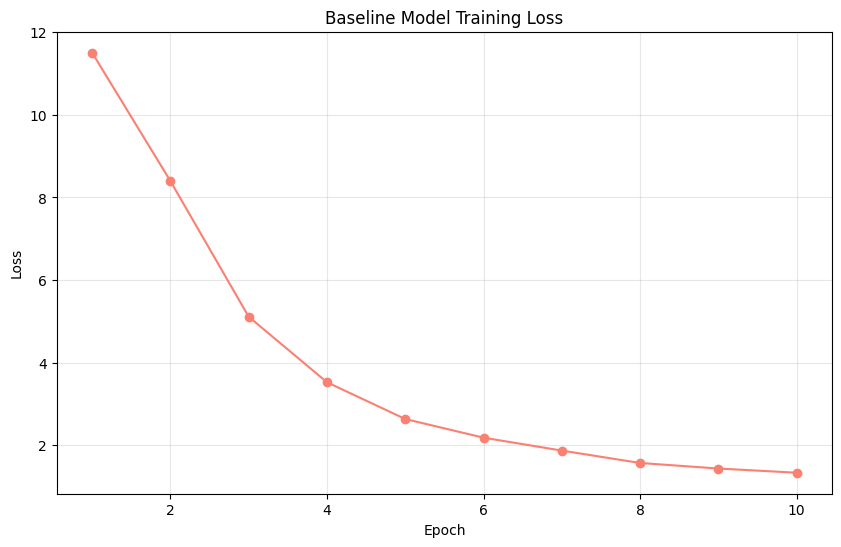

In [27]:
print("Training Naive Baseline Model (Raw Image -> Text)...")

NUM_EPOCHS = 10

baseline_train_losses = []

for epoch in range(NUM_EPOCHS):
    baseline_model.train()
    batch_losses = []
    
    baseline_pbar = tqdm(baseline_train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False)
    for imgs, targets, _ in baseline_pbar:
        imgs = imgs.to(device)
        targets = targets.to(device)
        
        baseline_optimizer.zero_grad()
        
        outputs = baseline_model(imgs)
        
        loss = 0
        for i in range(5):
            loss += reader_criterion(outputs[i], targets[:, i])
        
        loss.backward()
        baseline_optimizer.step()
        
        batch_losses.append(loss.item())
        baseline_pbar.set_postfix({'Summed Loss': loss.item()})
        
    epoch_loss = sum(batch_losses) / len(batch_losses)
    baseline_train_losses.append(epoch_loss)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Baseline Loss: {epoch_loss:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, NUM_EPOCHS+1), baseline_train_losses, marker='o', color='salmon')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline Model Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

## Inference and Evaluation

The model is trained, but neural networks output raw logits, not strings. In this step, we must bridge the gap between PyTorch tensors and human-readable text.

**Task:** Complete the cell below to perform a final visual evaluation.

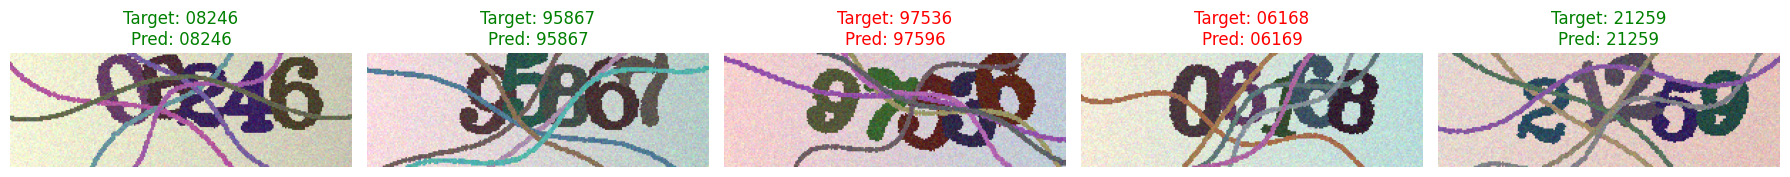

In [31]:
baseline_model.eval()

imgs, targets, true_texts = next(iter(baseline_train_loader)) 
imgs = imgs.to(device)

with torch.no_grad():
    outputs = baseline_model(imgs)

outputs_cpu = [out.cpu() for out in outputs]

batch_predictions = []

for batch_idx in range(imgs.shape[0]):
    predicted_string = ""
    for head_idx in range(5):
        # Get the predicted digit for this head and this batch item
        pred_digit = torch.argmax(outputs_cpu[head_idx][batch_idx]).item()
        predicted_string += str(pred_digit)
    batch_predictions.append(predicted_string)

num_display = 5
fig, axs = plt.subplots(1, num_display, figsize=(18, 4))

for i in range(num_display):
    img_display = imgs[i].cpu().permute(1, 2, 0).numpy()
    
    true_txt = true_texts[i]
    pred_txt = batch_predictions[i]
    
    axs[i].imshow(img_display)
    
    color = "green" if true_txt == pred_txt else "red"
    axs[i].set_title(f'Target: {true_txt}\nPred: {pred_txt}', color=color, fontsize=12)
    axs[i].axis('off')

plt.tight_layout()
plt.show()

## Final Evaluation

It is time for the final test. We will generate a fresh set of 500 unseen CAPTCHA images to evaluate both of our trained models. 

We will track two distinct metrics:
1.  **Character Accuracy:** Out of 2,500 total digits, how many did the model guess correctly?
2.  **Sequence Accuracy:** Out of 500 full CAPTCHAs, how many were guessed *perfectly*? (A single wrong character fails the entire sequence. This is the only metric that matters in the real world).

**The Value of Segmentation:** 
In the code below, we automatically route the unseen images through both pipelines. Notice how in **Pipeline B**, we must manually bridge the U-Net and the Sequence Reader by taking the `argmax` of the U-Net's multi-class output and converting it into a clean `0-1` binary mask before the Reader can process it.

**Task:** Run the cell below to evaluate your models and compare the results :)

Running Final Evaluation on 500 Unseen Samples...


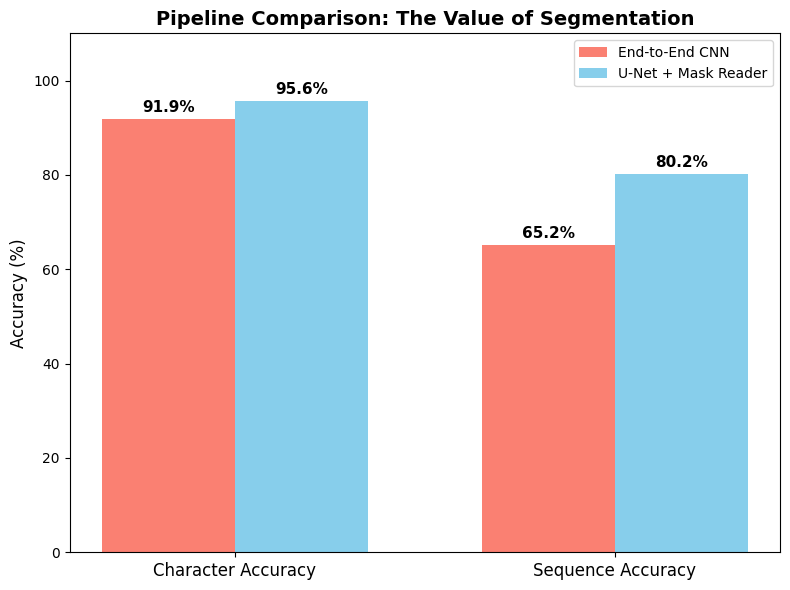

In [32]:
print("Running Final Evaluation on 500 Unseen Samples...")

test_dataset = BaselineCaptchaDataset(num_samples=500)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

baseline_model.eval()
model.eval()       
reader_model.eval()

base_char_correct = 0
base_seq_correct = 0

prop_char_correct = 0
prop_seq_correct = 0

total_chars = 0
total_seqs = 0

with torch.no_grad():
    for imgs, targets, _ in test_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        batch_size = imgs.shape[0]
        
        base_outs = baseline_model(imgs)
        base_preds = torch.stack([torch.argmax(base_outs[i], dim=1) for i in range(5)], dim=1)
        
        unet_logits = model(imgs)
        unet_multiclass_mask = torch.argmax(unet_logits, dim=1)
        
        unet_binary_mask = (unet_multiclass_mask > 0).float().unsqueeze(1)
        
        prop_outs = reader_model(unet_binary_mask)
        prop_preds = torch.stack([torch.argmax(prop_outs[i], dim=1) for i in range(5)], dim=1)
        

        base_char_matches = (base_preds == targets)
        prop_char_matches = (prop_preds == targets)
        
        base_char_correct += base_char_matches.sum().item()
        prop_char_correct += prop_char_matches.sum().item()
        
        base_seq_correct += base_char_matches.all(dim=1).sum().item()
        prop_seq_correct += prop_char_matches.all(dim=1).sum().item()
        
        total_chars += batch_size * 5
        total_seqs += batch_size

base_char_acc = (base_char_correct / total_chars) * 100
base_seq_acc = (base_seq_correct / total_seqs) * 100

prop_char_acc = (prop_char_correct / total_chars) * 100
prop_seq_acc = (prop_seq_correct / total_seqs) * 100

labels = ['Character Accuracy', 'Sequence Accuracy']
baseline_scores = [base_char_acc, base_seq_acc]
proposed_scores = [prop_char_acc, prop_seq_acc]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, baseline_scores, width, label='End-to-End CNN', color='salmon')
rects2 = ax.bar(x + width/2, proposed_scores, width, label='U-Net + Mask Reader', color='skyblue')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Pipeline Comparison: The Value of Segmentation', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 110)
ax.legend()

# Add text labels on top of the bars
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Conceptual Discussion and Analysis

Congratulations on completing the pipeline! Writing the code is only half the battle in deep learning; the other half is understanding *why* it works. 

1. Assuming your `SequenceReader` and your `BaselineModel` have the exact same architecture and roughly the same number of parameters, the proposed two-stage pipeline (U-Net -> Reader) almost certainly outperformed the Baseline. Theoretically, an end-to-end network *could* learn to do both the segmentation and the reading simultaneously. Why does forcing the network through the explicit U-Net bottleneck improve performance so drastically?
    - Two stage pipeline works better because it splits a hard problem into two easier one and UNet just separates digits from background then Reader only needs to recognize digits on a clean image and baseline model has to do everything at once that is much harder to learn

2. To read the 5 characters, we used a CNN that flattened its features into 5 parallel, independent linear heads. A common alternative for reading text is a Recurrent Neural Network (RNN) like an LSTM or GRU. Given the specific constraints of our generated dataset, why is our parallel CNN approach more computationally efficient, and why did we not *need* the sequential inductive bias of an RNN?
    - Our CAPTCHA always has exactly 5 digits and each digit doesnt depend on the others so we can predict all 5 parallelly instead sequentially that his is faster and simpler and a RNN would be slower and unnecessary here

3. We took the U-Net's rich, 12-class probability output and flattened it into a hard, 0-1 binary mask before passing it to the Sequence Reader. We effectively threw away the network's confidence scores and the individual digit class predictions. Why is this structurally beneficial for the Sequence Reader? What problem might occur if we passed the raw U-Net logits directly into the Reader instead?
    - Binary mask tells Reader "something is here" without confusing it with wrong digit labels from the UNet and if we gave raw UNet outputs then Reader would see wrong predictions on overlapping pixels and get confused and a clean mask is much easier to work with

4. We compared the Naive Baseline against our Proposed Pipeline. To keep the experiment controlled, we trained both architectures using the exact same hyperparameters. Is this truly a "fair" comparison? Think about the complexity of the optimization landscape for the Baseline model compared to the two-stage pipeline. How might significantly increasing the dataset size or the training duration (e.g., 100 epochs) affect the final performance of one model over the other?
    - With more data and longer training both models would improve but two stage model would likely still be better because it learns simpler tasks first and baseline has to learn everything at once that it takes much more data to do well